## INDEX

1. [Introduction](#1-introduction)
2. Research Questions & Objectives
3. Dataset Description
4. Data Loading
5. Data Overview
6. Data Quality Assessment
7. Univariate Analysis
[8. Bivariate Analysis](#8-bivariate-analysis)
9. Correlation Analysis
10. Key Insights

# 1. Introduction

This project analyzes a Portuguese bank marketing dataset to predict whether a client will subscribe to a term deposit.

# 2. Research Questions & Objectives

The goal is to build a classification model that predicts subscription outcomes and identify key drivers.

# 3. Data Description

The dataset contains information related to direct marketing campaigns conducted by a Portuguese banking institution.

The objective is to predict whether a client will subscribe to a term deposit.

The target variable is `y`, which indicates whether the client subscribed to a term deposit (yes/no).

The dataset includes:

- Client-related features (e.g., age, job, marital status)
- Campaign-related features (e.g., contact type, number of contacts)
- Socio-economic features (e.g., employment variation rate, consumer price index)


This is a binary classification problem.

# 4. Data Loading

This section imports the required libraries and loads the dataset into the notebook environment.

In [244]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
import missingno as msno
warnings.filterwarnings("ignore")

%matplotlib inline

csv = '../data/bank-additional-full.csv'

In [245]:
df = pd.read_csv(csv, sep=";")

# 5. Data Overview


This section provides an overview of the dataset structure, including dimensions, variable types, and general composition

Firsts and last lines of the data

In [246]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [247]:
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [248]:
df.shape

(41188, 21)

In [249]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [250]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [251]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [252]:
df['y'].unique()

array(['no', 'yes'], dtype=object)

#### Data Overview Summary

The dataset contains 41,188 observations and 21 features.

It includes a mix of numerical and categorical variables:
- 10 numerical features (5 integer and 5 float variables)
- 11 categorical features stored as object type

No missing values are detected based on the initial inspection. However, some categorical variables contain "unknown" values, which may represent missing or incomplete information and will be further analyzed in the data quality assessment.

The dataset appears well-structured, with consistent data types and no immediate issues in terms of data loading or formatting.

# 6. Data Quality Assessment

Checking the quality of the data

In [253]:
df.duplicated().sum()

12

The dataset contains 12 duplicated observations.

Duplicated records are further inspected to understand potential patterns or inconsistencies.

In [254]:
df[df.duplicated(keep=False)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


There is no missing values as na.

Checking the 'unknown' data

In [255]:
cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']

unknown_pct = {
    col: (df[col] == 'unknown').mean() * 100
    for col in cols
}

unknown_df = pd.DataFrame.from_dict(
    unknown_pct, orient='index', columns=['unknown_%']
).sort_values(by='unknown_%', ascending=False)

unknown_df

,unknown_%
default,20.872584
education,4.202680
housing,2.403613
loan,2.403613
job,0.801204
marital,0.194231


### Data Quality Summary

The dataset does not contain missing values in its raw form.

However, several categorical variables include "unknown" values, which likely represent missing or incomplete information. The most significant issue is observed in the `default` variable (~20%), suggesting a substantial amount of unreported or unavailable information.

Other variables contain relatively small proportions of "unknown" values and are less likely to impact the analysis significantly.

A small number of duplicated records are identified.

These issues will be addressed in the feature engineering stage.

# 7. Univariate Analysis

**Objective:** Analyze the distribution of individual variables to understand their behavior, identify imbalances, and detect potential issues such as rare categories or outliers.

To structure the analysis, features are grouped into three categories:

- Client-related features  
- Campaign-related features  
- Socio-economic context features  

This segmentation improves interpretability and organization of the analysis.

## 7.1 Client-related Features

### 7.1.1 Age

In [256]:
bank_client = df[['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']]

In [257]:
# ======== AGE =========
print('Min age: ', bank_client['age'].min())
print('Max age: ', bank_client['age'].max())
print('Null Values: ', bank_client['age'].isnull().any())

Min age:  17
Max age:  98
Null Values:  False


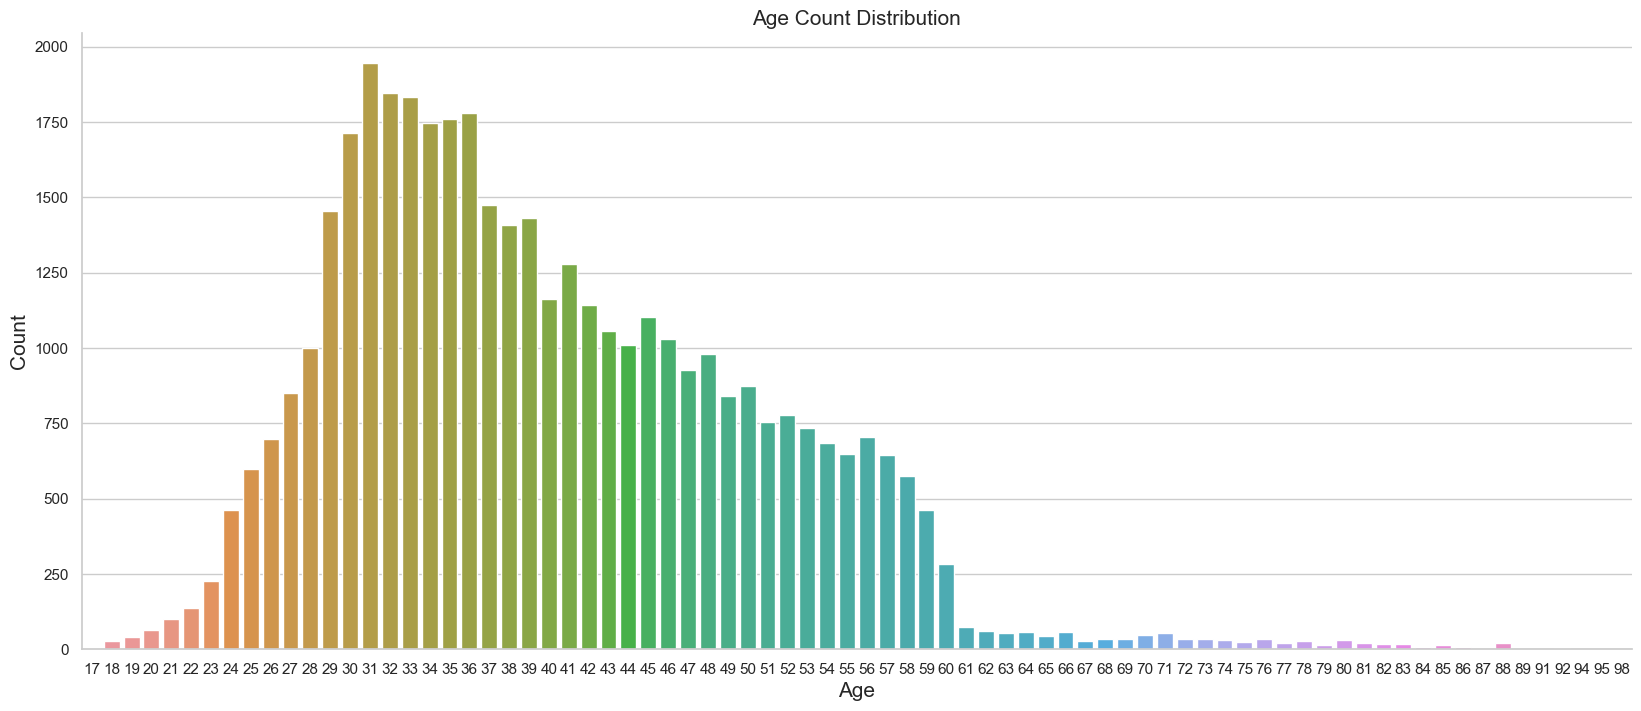

In [258]:
fig, ax = plt.subplots()
fig.set_size_inches(20, 8)
sns.countplot(x = 'age', data = df)
ax.set_xlabel('Age', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title('Age Count Distribution', fontsize=15)
sns.despine()

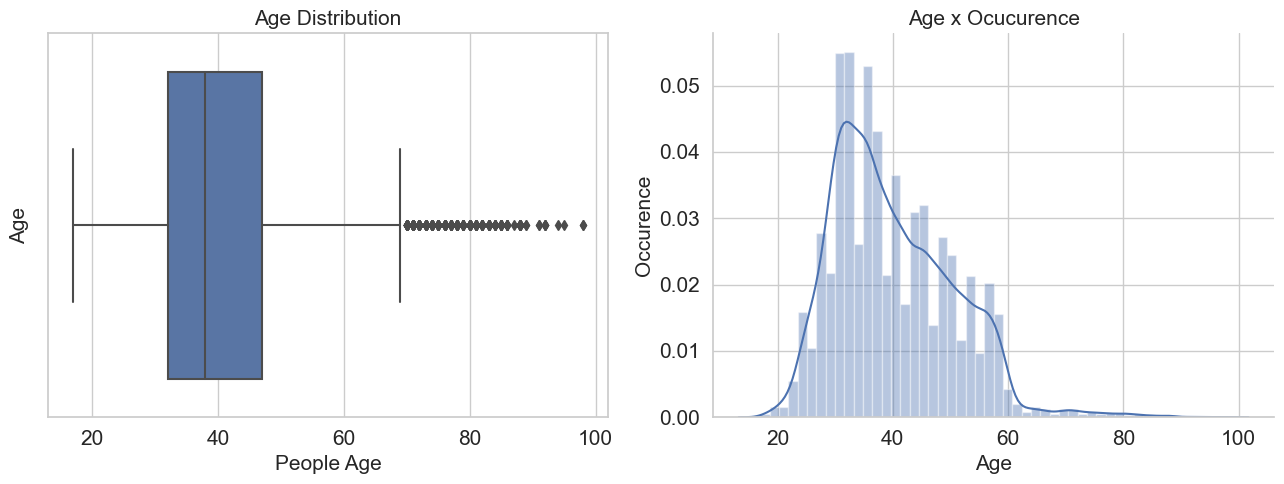

In [259]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (13, 5))
sns.boxplot(x = 'age', data = bank_client, orient = 'v', ax = ax1)
ax1.set_xlabel('People Age', fontsize=15)
ax1.set_ylabel('Age', fontsize=15)
ax1.set_title('Age Distribution', fontsize=15)
ax1.tick_params(labelsize=15)

sns.distplot(bank_client['age'], ax = ax2)
sns.despine(ax = ax2)
ax2.set_xlabel('Age', fontsize=15)
ax2.set_ylabel('Occurence', fontsize=15)
ax2.set_title('Age x Ocucurence', fontsize=15)
ax2.tick_params(labelsize=15)

plt.subplots_adjust(wspace=0.5)
plt.tight_layout() 

In [260]:
print('1º Quartile: ', bank_client['age'].quantile(q = 0.25))
print('2º Quartile: ', bank_client['age'].quantile(q = 0.50))
print('3º Quartile: ', bank_client['age'].quantile(q = 0.75))
print('4º Quartile: ', bank_client['age'].quantile(q = 1.00))
#CALCULO DE OUTLIERS
  # Interquartile range, IQR = Q3 - Q1
  # lower 1.5*IQR whisker = Q1 - 1.5 * IQR 
  # Upper 1.5*IQR whisker = Q3 + 1.5 * IQR
    
print('Las edades por encima de: ', bank_client['age'].quantile(q = 0.75) + 
                      1.5*(bank_client['age'].quantile(q = 0.75) - bank_client['age'].quantile(q = 0.25)), 'son outliers')

1º Quartile:  32.0
2º Quartile:  38.0
3º Quartile:  47.0
4º Quartile:  98.0
Las edades por encima de:  69.5 son outliers


In [261]:
print('Cantidad de outliers: ', bank_client[bank_client['age'] > 69.6]['age'].count())
print('Cantidad de clientes: ', len(bank_client))
#Outliers in %
print('Porcentaje de outliers:', round(bank_client[bank_client['age'] > 69.6]['age'].count()*100/len(bank_client),2), '%')

Cantidad de outliers:  469
Cantidad de clientes:  41188
Porcentaje de outliers: 1.14 %


The age variable ranges from 17 to 98, with the majority of clients concentrated between approximately 30 and 50 years old.

The distribution is slightly right-skewed, with a long tail towards older ages. A small proportion of observations (~1.1%) are identified as outliers above 69.5 years.

These outliers are limited in size and are unlikely to significantly impact the analysis, although the skewness of the distribution may be relevant for modeling.

### 7.1.2 Job

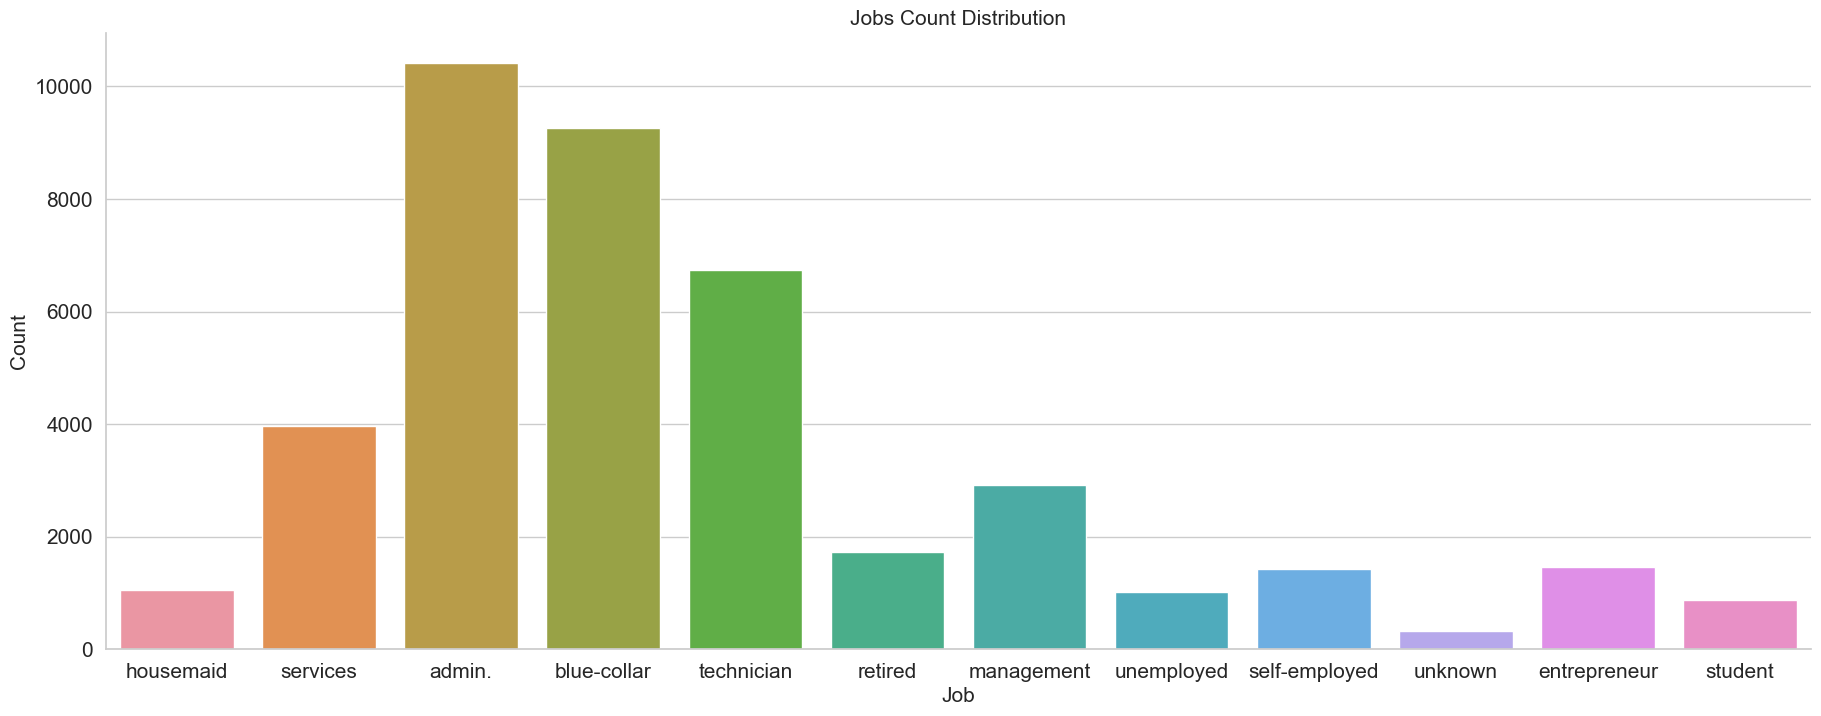

In [262]:
fig, ax = plt.subplots()
fig.set_size_inches(22, 8)
sns.countplot(x = 'job', data = bank_client)
ax.set_xlabel('Job', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title('Jobs Count Distribution', fontsize=15)
ax.tick_params(labelsize=15)
sns.despine()

The distribution of job categories is uneven, with a clear concentration in administrative, blue-collar, and technician roles.

Less represented categories include unemployed, housemaid, and student, while the "unknown" category is present but relatively small.

This imbalance suggests that a few occupational groups dominate the dataset, which may influence the model's ability to differentiate between clients based on job.

The presence of an "unknown" category indicates missing or incomplete information that may need to be handled during feature engineering.

### 7.1.3 Marital

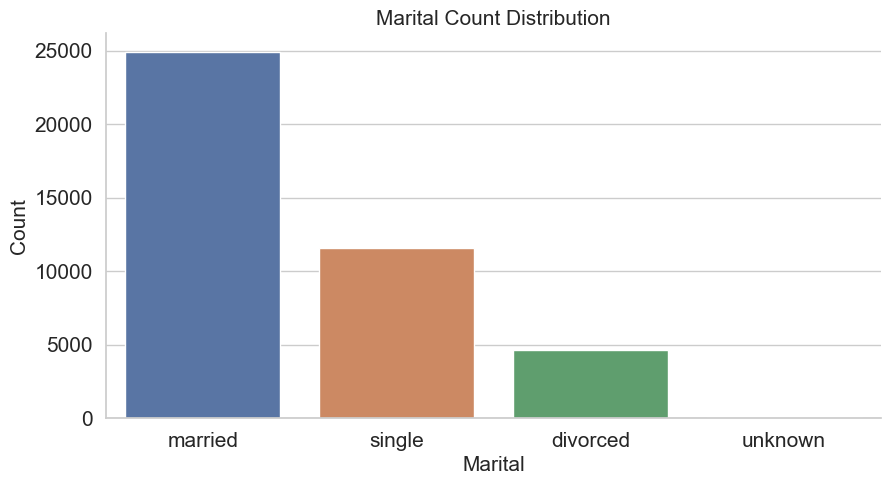

In [263]:
fig, ax = plt.subplots()
fig.set_size_inches(10, 5)
sns.countplot(x = 'marital', data = bank_client)
ax.set_xlabel('Marital', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title('Marital Count Distribution', fontsize=15)
ax.tick_params(labelsize=15)
sns.despine()

The marital status variable is dominated by married individuals, followed by single and divorced categories.

The "unknown" category is negligible, indicating minimal missing or incomplete information for this feature.

The strong imbalance suggests that marital status may have limited variability, which could reduce its discriminative power in modeling.

### 7.1.4 Education

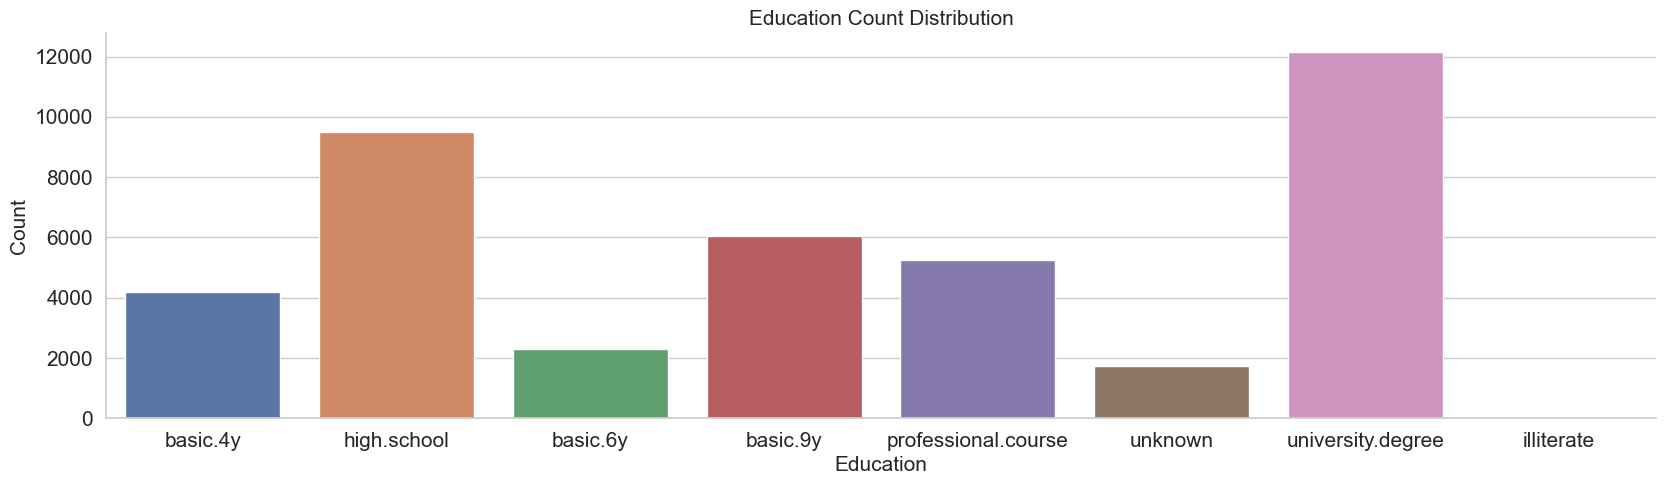

In [264]:
fig, ax = plt.subplots()
fig.set_size_inches(20, 5)
sns.countplot(x = 'education', data = bank_client)
ax.set_xlabel('Education', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title('Education Count Distribution', fontsize=15)
ax.tick_params(labelsize=15)
sns.despine()

The education variable shows a diverse distribution, with a concentration in university degree and high school levels, followed by basic education categories.

Lower frequency categories such as illiterate are almost negligible, while the "unknown" category is present but represents a relatively small proportion of the dataset.

The presence of multiple education levels suggests potential granularity in client profiles, although some categories may contribute limited predictive value due to low representation.

### 7.1.5 Default, Housing and Loan

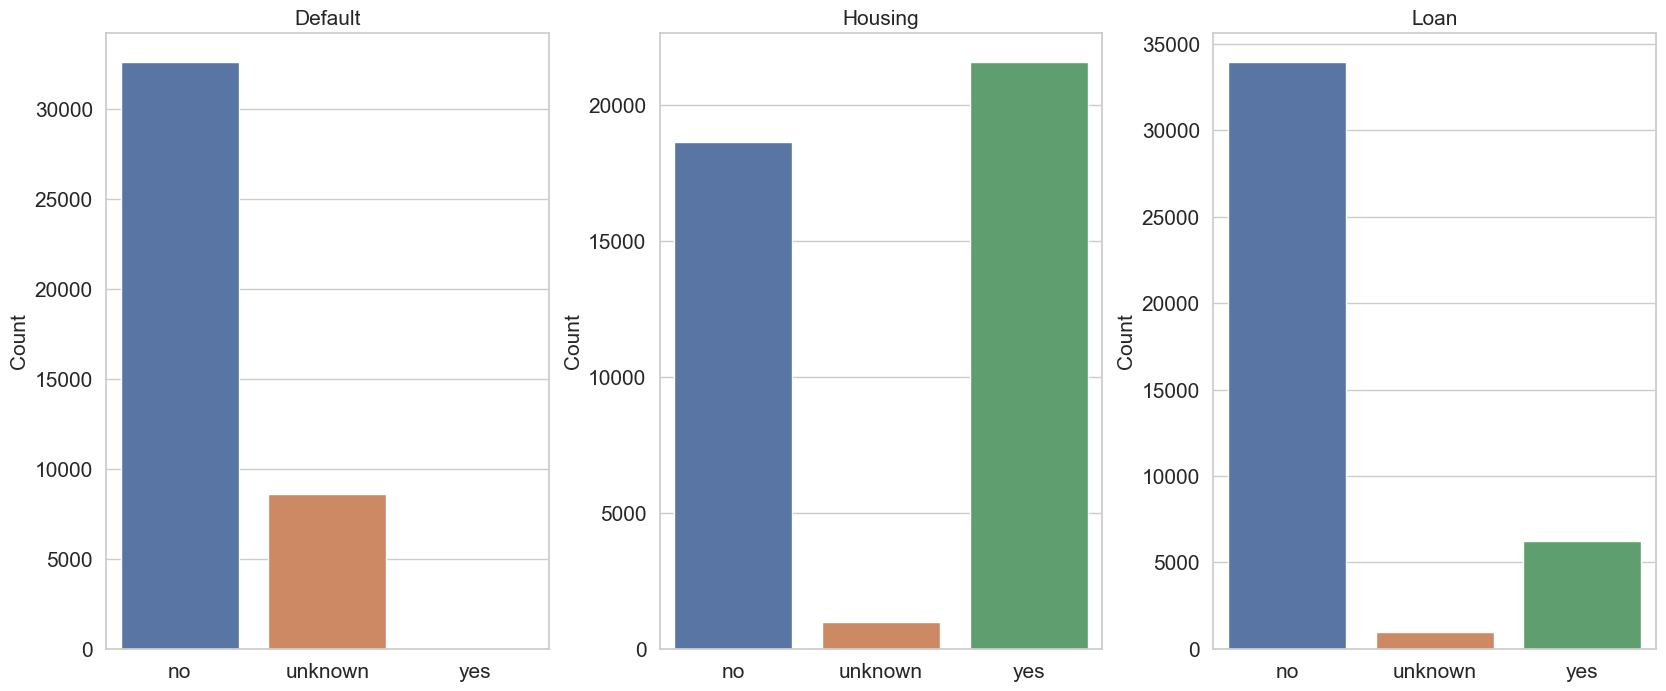

In [265]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows = 1, ncols = 3, figsize = (20,8))
sns.countplot(x = 'default', data = bank_client, ax = ax1, order = ['no', 'unknown', 'yes'])
ax1.set_title('Default', fontsize=15)
ax1.set_xlabel('')
ax1.set_ylabel('Count', fontsize=15)
ax1.tick_params(labelsize=15)

# Housing, has housing loan ?
sns.countplot(x = 'housing', data = bank_client, ax = ax2, order = ['no', 'unknown', 'yes'])
ax2.set_title('Housing', fontsize=15)
ax2.set_xlabel('')
ax2.set_ylabel('Count', fontsize=15)
ax2.tick_params(labelsize=15)

# Loan, has personal loan ?
sns.countplot(x = 'loan', data = bank_client, ax = ax3, order = ['no', 'unknown', 'yes'])
ax3.set_title('Loan', fontsize=15)
ax3.set_xlabel('')
ax3.set_ylabel('Count', fontsize=15)
ax3.tick_params(labelsize=15)

plt.subplots_adjust(wspace=0.25)

In [266]:
print('Default:\n No credit in default:'     , bank_client[bank_client['default'] == 'no']     ['age'].count(),
              '\n Unknown credit in default:', bank_client[bank_client['default'] == 'unknown']['age'].count(),
              '\n Yes to credit in default:' , bank_client[bank_client['default'] == 'yes']    ['age'].count())

Default:
 No credit in default: 32588 
 Unknown credit in default: 8597 
 Yes to credit in default: 3


In [267]:
print('Housing:\n No housing in loan:'     , bank_client[bank_client['housing'] == 'no']     ['age'].count(),
              '\n Unknown housing in loan:', bank_client[bank_client['housing'] == 'unknown']['age'].count(),
              '\n Yes to housing in loan:' , bank_client[bank_client['housing'] == 'yes']    ['age'].count())

Housing:
 No housing in loan: 18622 
 Unknown housing in loan: 990 
 Yes to housing in loan: 21576


In [268]:
print('Housing:\n No to personal loan:'     , bank_client[bank_client['loan'] == 'no']     ['age'].count(),
              '\n Unknown to personal loan:', bank_client[bank_client['loan'] == 'unknown']['age'].count(),
              '\n Yes to personal loan:'    , bank_client[bank_client['loan'] == 'yes']    ['age'].count())

Housing:
 No to personal loan: 33950 
 Unknown to personal loan: 990 
 Yes to personal loan: 6248


The `default` variable is highly imbalanced, with almost all observations classified as "no" and only a negligible number of "yes" cases. The "unknown" category represents a significant proportion (~20%), indicating missing or sensitive information that may carry predictive signal.

The `housing` variable is more balanced, with a relatively even distribution between "yes" and "no", while the "unknown" category remains minimal.

The `loan` variable is strongly skewed towards "no", with a smaller proportion of clients having personal loans. The "unknown" category is again negligible.

Overall, these variables exhibit varying levels of imbalance, particularly `default`, which may limit its direct usefulness but could still provide signal through the "unknown" category.

Campaign-related features describe what happened during the interaction, capturing how the client was contacted and how the campaign unfolded.

## 7.2 Campaign Features

### 7.2.1 Contact

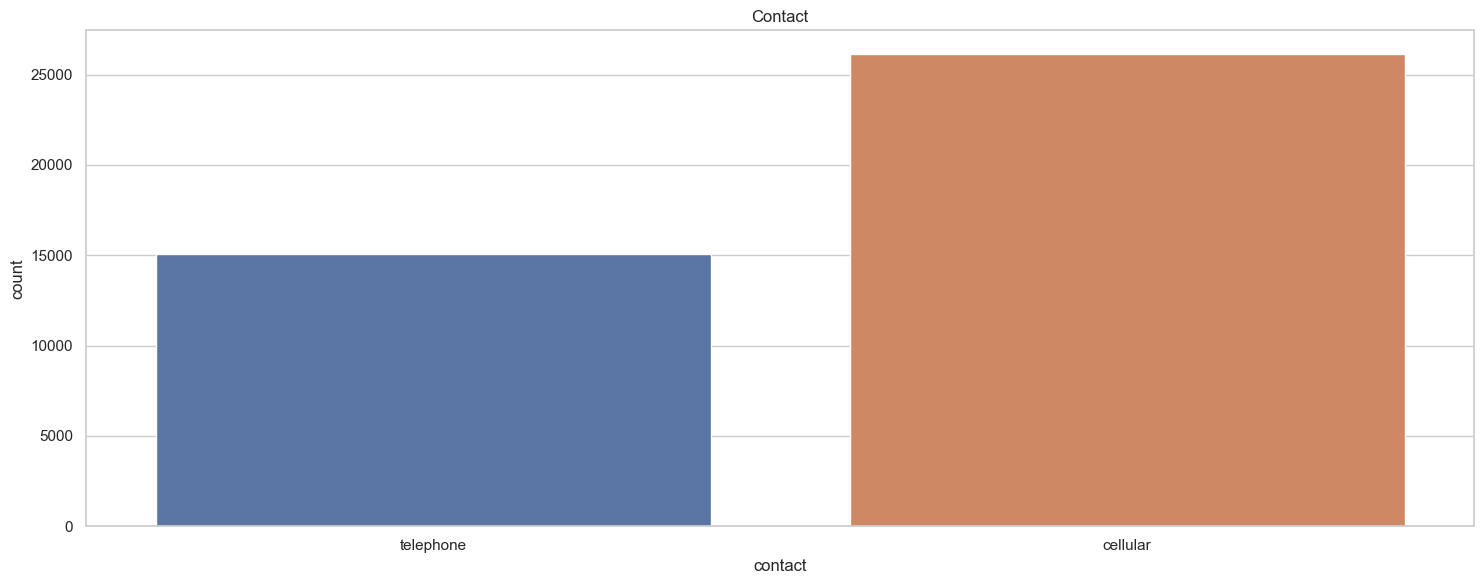

In [269]:
fig, (ax1)= plt.subplots(nrows=1, ncols=1, figsize=(15,6))

sns.countplot(x='contact', data=df, ax=ax1)
ax1.set_title('Contact')

plt.tight_layout()

The `contact` variable shows a higher use of cellular communication compared to telephone, indicating a preference for more direct contact methods.

### 7.2.2 Month

Text(0.5, 1.0, 'Month')

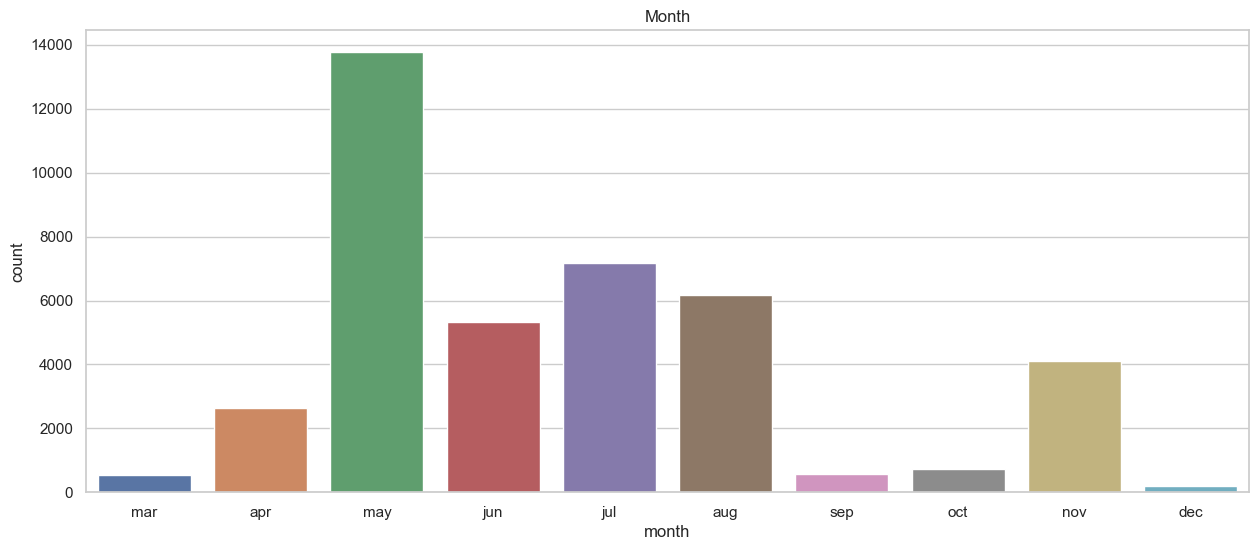

In [270]:
fig, (ax2)= plt.subplots(nrows=1, ncols=1, figsize=(15,6))

sns.countplot(x='month', data=df, ax=ax2,
              order=['mar','apr','may','jun','jul','aug','sep','oct','nov','dec'])
ax2.set_title('Month')

The `month` variable is highly imbalanced, with a strong concentration of campaigns in May, followed by July and August, suggesting a temporal bias in campaign execution that may affect model generalization.

### 7.2.3 Day of Week

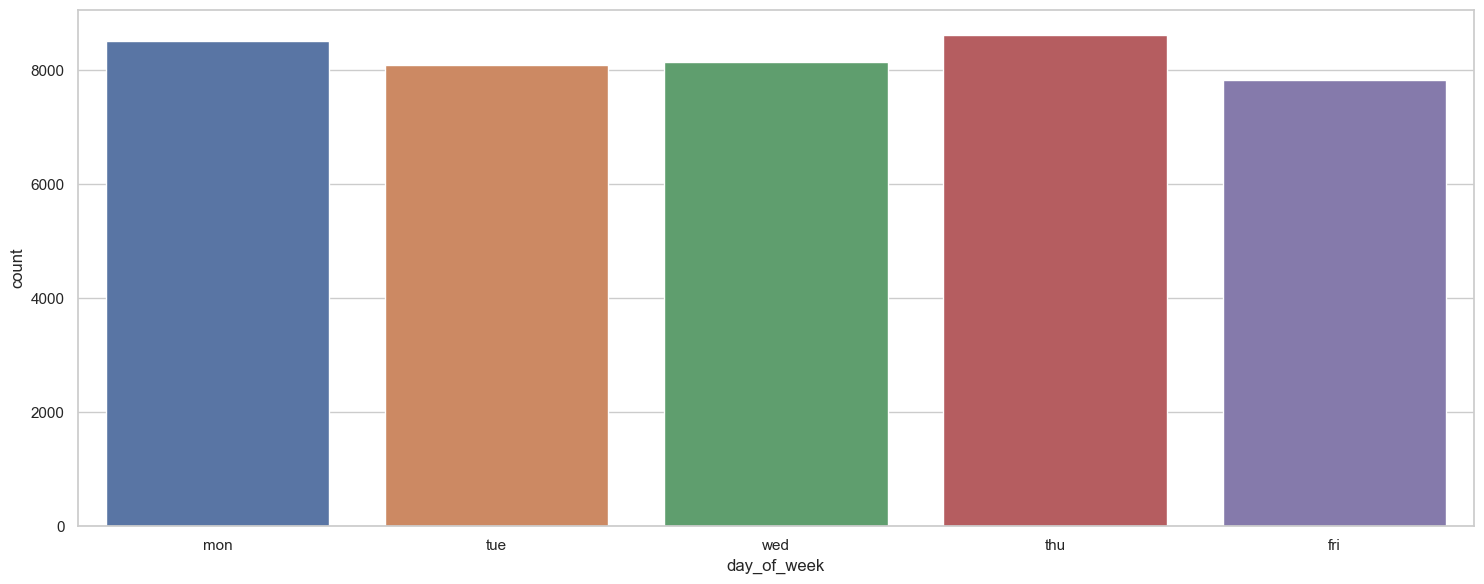

In [271]:
fig, (ax3)= plt.subplots(nrows=1, ncols=1, figsize=(15,6))

sns.countplot(x='day_of_week', data=df, ax=ax3)
ax1.set_title('day_of_week')

plt.tight_layout()


The `day_of_week` variable appears relatively uniform, indicating limited variation in contact frequency across weekdays and potentially low predictive value.

### 7.2.4 Duration

In [272]:
bank_related = df[
    ['contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']
]

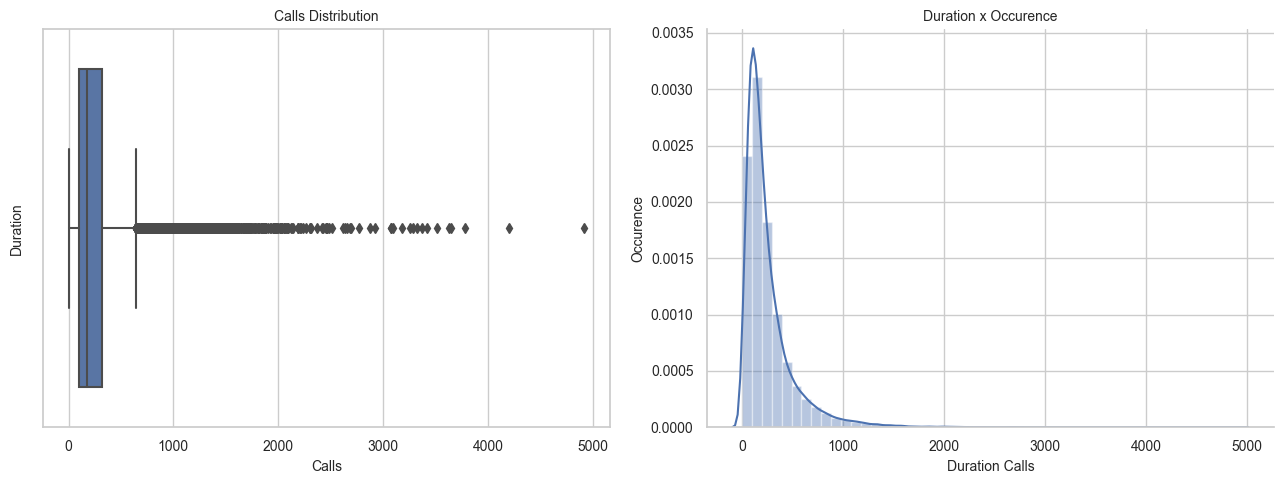

In [273]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (13, 5))
sns.boxplot(x = 'duration', data = bank_related, orient = 'v', ax = ax1)
ax1.set_xlabel('Calls', fontsize=10)
ax1.set_ylabel('Duration', fontsize=10)
ax1.set_title('Calls Distribution', fontsize=10)
ax1.tick_params(labelsize=10)

sns.distplot(bank_related['duration'], ax = ax2)
sns.despine(ax = ax2)
ax2.set_xlabel('Duration Calls', fontsize=10)
ax2.set_ylabel('Occurence', fontsize=10)
ax2.set_title('Duration x Occurence', fontsize=10)
ax2.tick_params(labelsize=10)

plt.subplots_adjust(wspace=0.5)
plt.tight_layout()

In [274]:
print("Max duration  call in minutes:  ", round((bank_related['duration'].max()/60),1))
print("Min duration  call in minutes:   ", round((bank_related['duration'].min()/60),1))
print("Mean duration call in minutes:   ", round((bank_related['duration'].mean()/60),1))
print("STD duration  call in minutes:   ", round((bank_related['duration'].std()/60),1))

Max duration  call in minutes:   82.0
Min duration  call in minutes:    0.0
Mean duration call in minutes:    4.3
STD duration  call in minutes:    4.3


In [275]:
print('1º Quartile: ', bank_related['duration'].quantile(q = 0.25))
print('2º Quartile: ', bank_related['duration'].quantile(q = 0.50))
print('3º Quartile: ', bank_related['duration'].quantile(q = 0.75))
print('4º Quartile: ', bank_related['duration'].quantile(q = 1.00))
#CALCULO DE OUTLIERS:
  # Interquartile range, IQR = Q3 - Q1
  # lower 1.5*IQR whisker = Q1 - 1.5 * IQR 
  # Upper 1.5*IQR whisker = Q3 + 1.5 * IQR
    
print('Llamadas con duracion mayor a: ', bank_related['duration'].quantile(q = 0.75) + 
                      1.5*(bank_related['duration'].quantile(q = 0.75) - bank_related['duration'].quantile(q = 0.25)), 'son outliers')

1º Quartile:  102.0
2º Quartile:  180.0
3º Quartile:  319.0
4º Quartile:  4918.0
Llamadas con duracion mayor a:  644.5 son outliers


In [276]:
print('Numerber of outliers: ', bank_related[bank_related['duration'] > 644.5]['duration'].count())
print('Number of clients: ', len(bank_related))
#Outliers in %
print('Outliers are:', round(bank_related[bank_related['duration'] > 644.5]['duration'].count()*100/len(bank_related),2), '%')

Numerber of outliers:  2963
Number of clients:  41188
Outliers are: 7.19 %


The duration variable shows a highly right-skewed distribution, with most calls concentrated at lower values and a long tail of longer durations.

A significant number of outliers (~7.2%) are present, with some calls reaching extreme durations. This indicates that a small subset of observations may disproportionately influence the analysis.

Importantly, call duration is likely strongly correlated with the target variable, as longer interactions may increase the probability of subscription. However, this feature may introduce data leakage, since duration is only known after the call has taken place.

### 7.2.5 Campaign Interaction Features

#### 7.2.5.1 Campaign

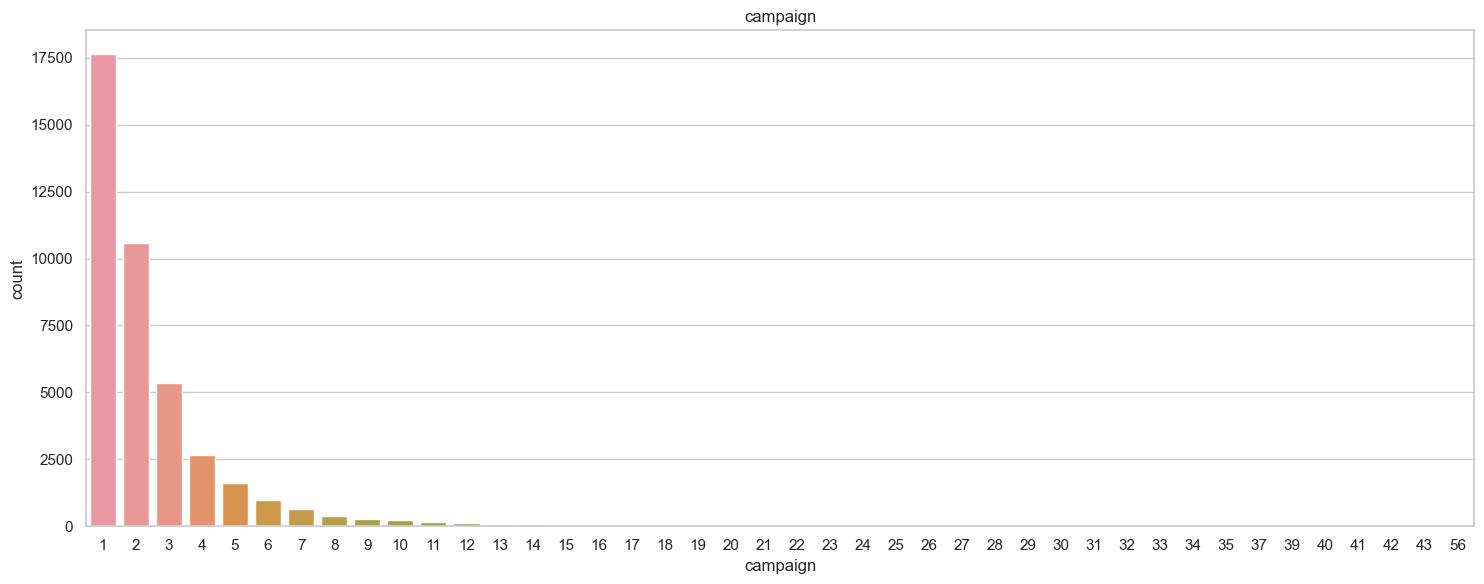

In [277]:
fig, (ax1)= plt.subplots(nrows=1, ncols=1, figsize=(15,6))

sns.countplot(x='campaign', data=df, ax=ax1)
ax1.set_title('campaign')

plt.tight_layout()

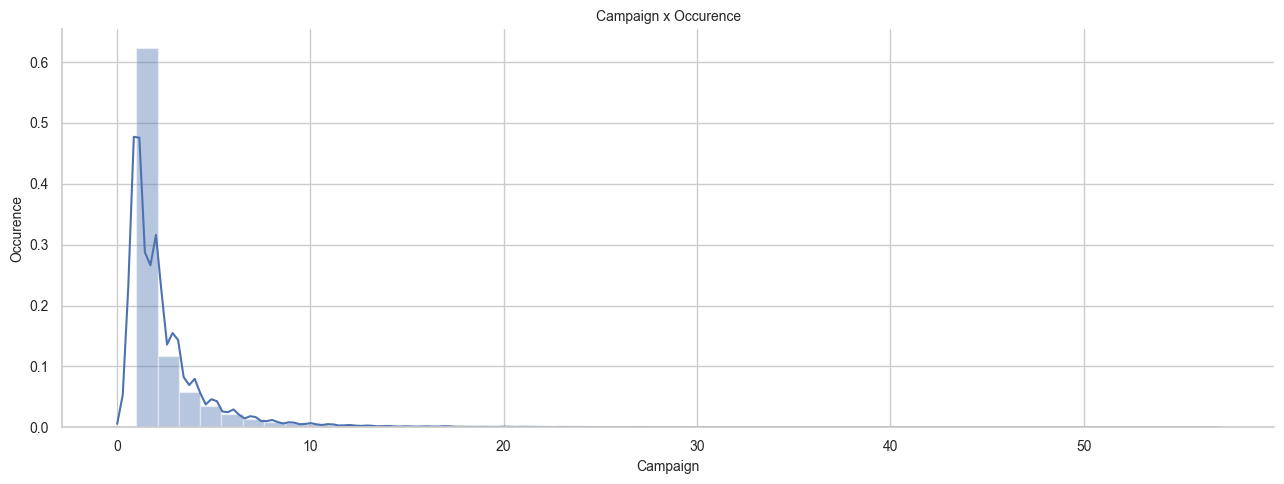

In [278]:
fig, (ax2) = plt.subplots(nrows = 1, ncols = 1, figsize = (13, 5))
sns.distplot(bank_related['campaign'], ax = ax2)
sns.despine(ax = ax2)
ax2.set_xlabel('Campaign', fontsize=10)
ax2.set_ylabel('Occurence', fontsize=10)
ax2.set_title('Campaign x Occurence', fontsize=10)
ax2.tick_params(labelsize=10)

plt.subplots_adjust(wspace=0.5)
plt.tight_layout()

The `campaign` variable shows a highly right-skewed distribution, with most observations concentrated in the first few contact attempts.

Values of 1 and 2 clearly dominate the distribution, while higher numbers of contacts become increasingly rare.

This suggests that most clients were contacted only a limited number of times during the campaign, whereas repeated contact attempts were uncommon and may reflect harder-to-convert cases.

#### 7.2.5.2 Pdays

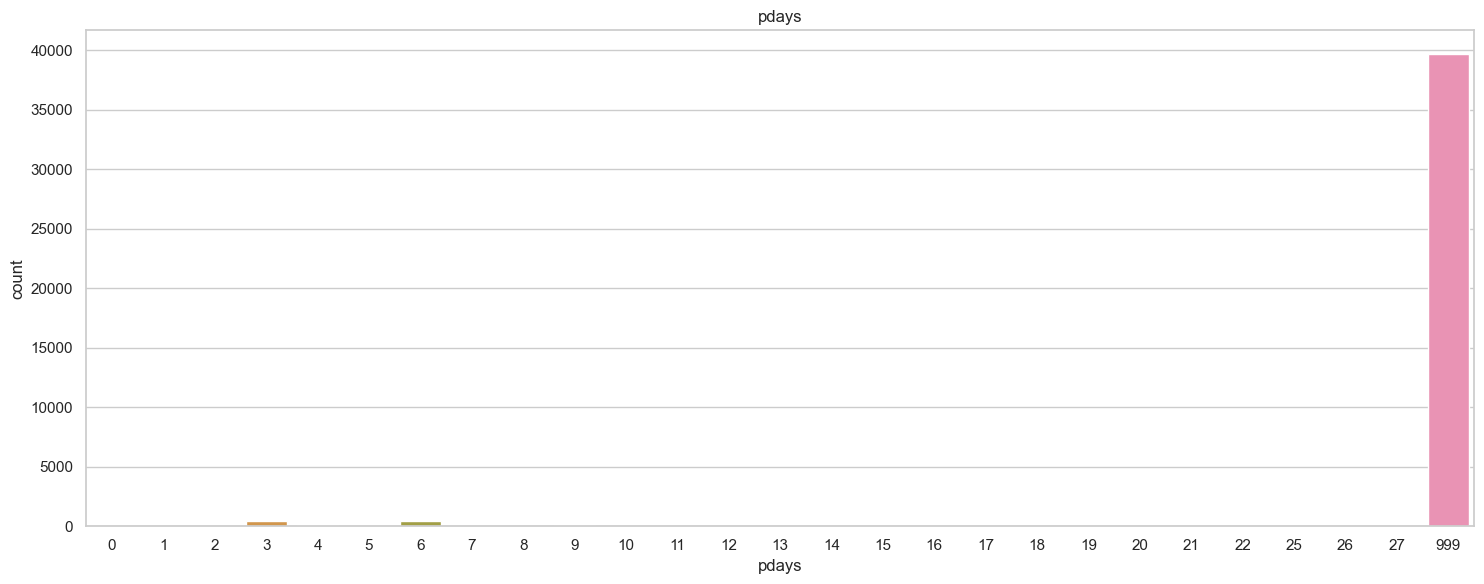

In [279]:
fig, (ax1)= plt.subplots(nrows=1, ncols=1, figsize=(15,6))

sns.countplot(x='pdays', data=df, ax=ax1)
ax1.set_title('pdays')

plt.tight_layout()

The `pdays` variable shows a highly concentrated distribution at the value 999, indicating that most clients were not previously contacted.

Other values are relatively small and represent the number of days since the last contact for previously contacted clients.

This suggests that the dataset is largely composed of clients without prior campaign history, while a smaller subset has been contacted in the past.

The value 999 should be treated as a separate category rather than a continuous numeric value.

#### 7.2.5.3 Previuos

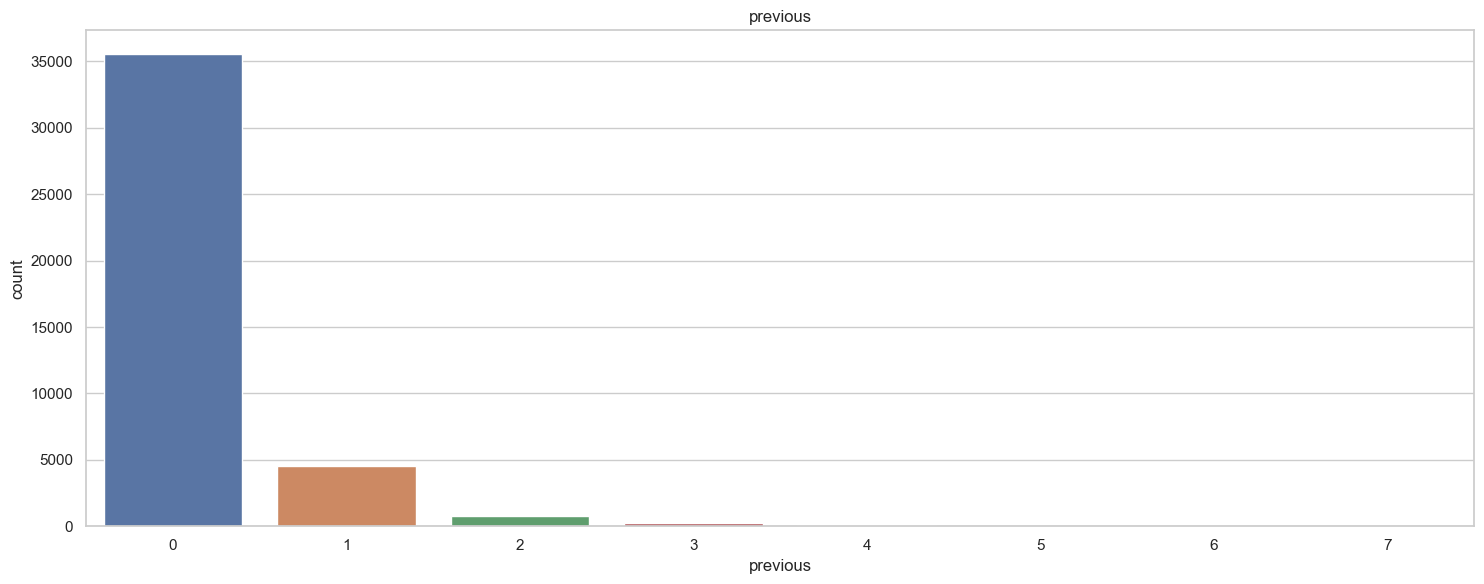

In [280]:
fig, (ax1)= plt.subplots(nrows=1, ncols=1, figsize=(15,6))

sns.countplot(x='previous', data=df, ax=ax1)
ax1.set_title('previous')


plt.tight_layout()

The `previous` variable shows a strong concentration at the value 0, indicating that most clients were not previously contacted.

Values greater than 0 are relatively rare and represent the number of prior contacts for a given client.

This limited variability suggests that most clients lack historical interaction data, reinforcing the pattern observed in the `pdays` variable.

#### 7.2.5.4 Poutcome

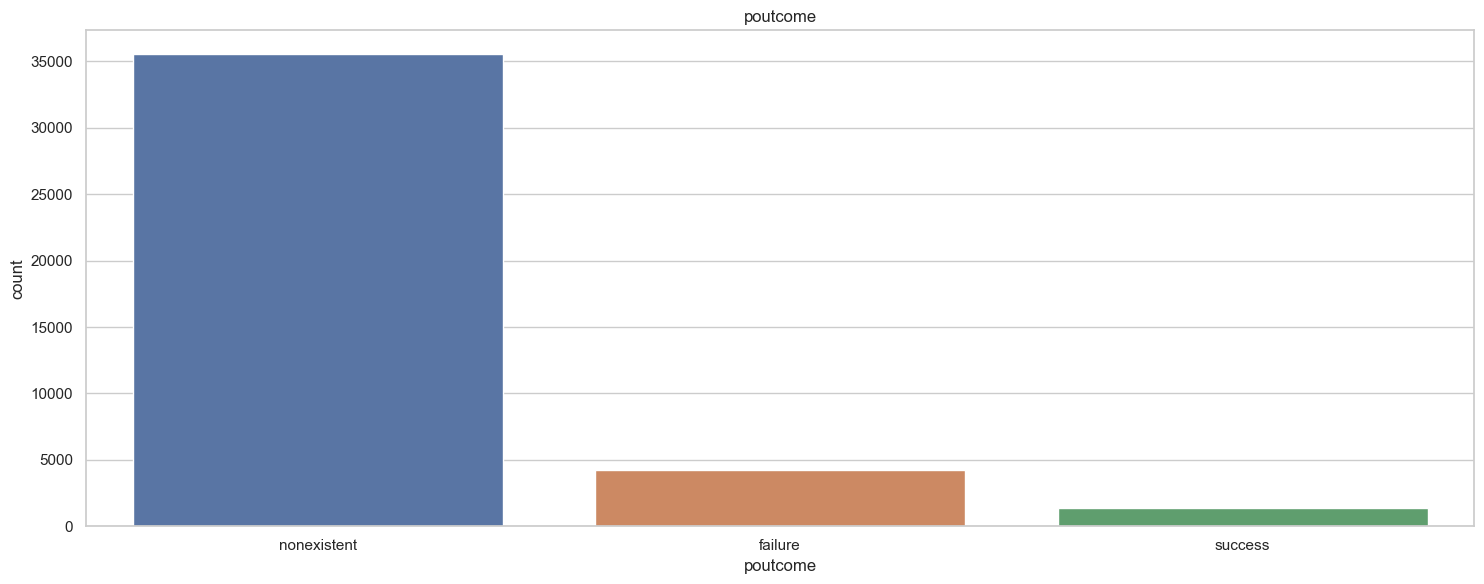

In [281]:
fig, (ax1)= plt.subplots(nrows=1, ncols=1, figsize=(15,6))

sns.countplot(x='poutcome', data=df, ax=ax1)
ax1.set_title('poutcome')

plt.tight_layout()

The `poutcome` variable represents the outcome of the previous marketing campaign and is dominated by the "nonexistent" category.

This indicates that the majority of clients were not previously contacted, which is consistent with the patterns observed in the `previous` and `pdays` variables.

The remaining categories, "failure" and "success", are less frequent, with "success" representing a small subset of clients who responded positively in past campaigns.

---
Overall, campaign interaction variables suggest that most clients have little to no prior contact history, with only a small subset having been previously engaged.

# 8. Bivariate Analysis

**Objective:** Analyze the relationship between input variables and the target variable (`y`) to identify patterns, dependencies, and potential predictors of client subscription.

The analysis focuses on comparing the distribution of features across target classes, allowing us to detect variables with strong discriminatory power.

Both categorical and numerical variables are evaluated to understand how client characteristics, campaign interactions, and contextual factors influence the outcome.hago en el analisis bivariable estas..

#### 8.1 🔹 High Priority

             count  conversion_rate
poutcome                           
success       1373         0.651129
failure       4252         0.142286
nonexistent  35563         0.088322


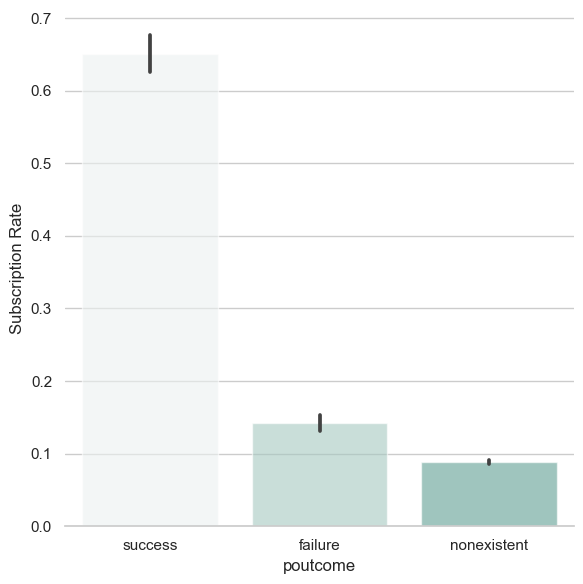

In [282]:
# Binary target for conversion analysis
df['y_bin'] = df['y'].map({'no': 0, 'yes': 1})

# Variable to analyze
var = 'poutcome'
label = 'poutcome'

# Summary table
summary = (
    df.groupby(var)
      .agg(
          count=('y_bin', 'size'),
          conversion_rate=('y_bin', 'mean')
      )
      .sort_values(by='conversion_rate', ascending=False)
)

print(summary)

# Plot
g = sns.catplot(
    data=df,
    kind="bar",
    x=var,
    y="y_bin",
    order=summary.index,
    height=6,
    alpha=0.6,
    palette="light:#5A9"
)

g.despine(left=True)
g.set_axis_labels(label, "Subscription Rate")
g.set_titles(f"Conversion Rate by {label}")

           count  conversion_rate
contact                          
cellular   26144         0.147376
telephone  15044         0.052313


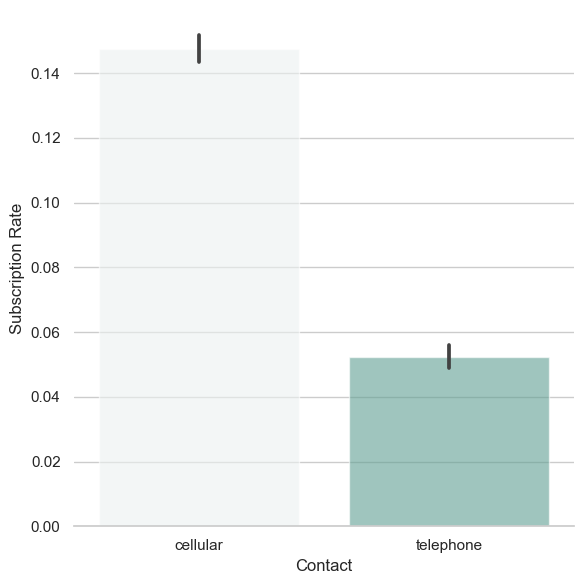

In [283]:
# Binary target for conversion analysis
df['y_bin'] = df['y'].map({'no': 0, 'yes': 1})

# Variable to analyze
var = 'contact'
label = 'Contact'

# Summary table
summary = (
    df.groupby(var)
      .agg(
          count=('y_bin', 'size'),
          conversion_rate=('y_bin', 'mean')
      )
      .sort_values(by='conversion_rate', ascending=False)
)

print(summary)

# Plot
g = sns.catplot(
    data=df,
    kind="bar",
    x=var,
    y="y_bin",
    order=summary.index,
    height=6,
    alpha=0.6,
    palette="light:#5A9"
)

g.despine(left=True)
g.set_axis_labels(label, "Subscription Rate")
g.set_titles(f"Conversion Rate by {label}")

       count  conversion_rate
month                        
mar      546         0.505495
dec      182         0.489011
sep      570         0.449123
oct      718         0.438719
apr     2632         0.204787
aug     6178         0.106021
jun     5318         0.105115
nov     4101         0.101439
jul     7174         0.090466
may    13769         0.064347


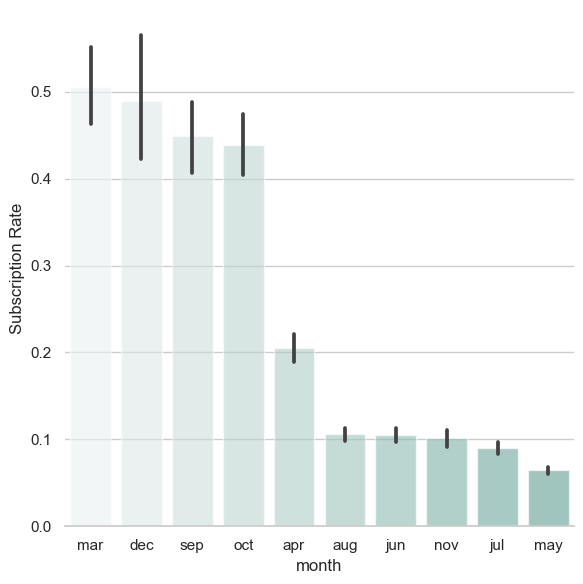

In [284]:
# Binary target for conversion analysis
df['y_bin'] = df['y'].map({'no': 0, 'yes': 1})

# Variable to analyze
var = 'month'
label = 'month'

# Summary table
summary = (
    df.groupby(var)
      .agg(
          count=('y_bin', 'size'),
          conversion_rate=('y_bin', 'mean')
      )
      .sort_values(by='conversion_rate', ascending=False)
)

print(summary)

# Plot
g = sns.catplot(
    data=df,
    kind="bar",
    x=var,
    y="y_bin",
    order=summary.index,
    height=6,
    alpha=0.6,
    palette="light:#5A9"
)

g.despine(left=True)
g.set_axis_labels(label, "Subscription Rate")
g.set_titles(f"Conversion Rate by {label}")

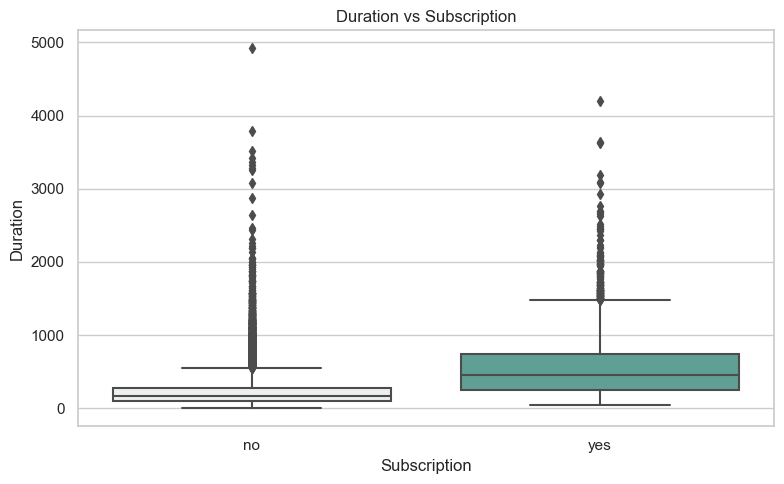

In [285]:
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(
    x='y',
    y='duration',
    data=df,
    palette="light:#5A9"
)

ax.set_title('Duration vs Subscription')
ax.set_xlabel('Subscription')
ax.set_ylabel('Duration')

plt.tight_layout()

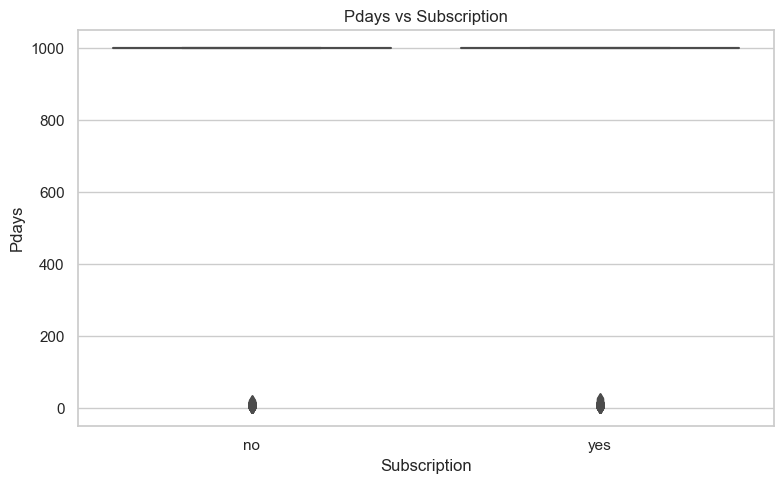

In [286]:
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(
    x='y',
    y='pdays',
    data=df,
    palette="light:#5A9"
)

ax.set_title('Pdays vs Subscription')
ax.set_xlabel('Subscription')
ax.set_ylabel('Pdays')

plt.tight_layout()

 Overview

The analysis of high-impact variables reveals strong patterns associated with client subscription behavior.

The `poutcome` variable emerges as one of the most influential predictors. Clients with a previous successful campaign outcome show a significantly higher conversion rate (~65%) compared to those with failed or nonexistent prior interactions. This highlights the importance of historical engagement and prior success as key drivers of future subscription.

The `contact` variable also shows a clear effect, with cellular communication achieving nearly three times higher conversion rates than telephone. This suggests that the communication channel plays a critical role in campaign effectiveness.

Temporal patterns are evident in the `month` variable. Certain months such as March, December, and September exhibit substantially higher conversion rates, while others like May and July perform considerably worse. This indicates a strong seasonality effect, although some months may be influenced by smaller sample sizes.

From a numerical perspective, `duration` shows a clear separation between target classes. Longer call durations are strongly associated with successful outcomes, making it one of the most predictive variables in the dataset. However, this variable may introduce data leakage, as it is only known after the interaction has taken place.

Finally, the `pdays` variable is dominated by the value 999, indicating that most clients were not previously contacted. This reinforces the observation that the dataset largely consists of clients without prior campaign history, with only a small subset having previous interactions.

#### 8.2 🔹 Medium Priority

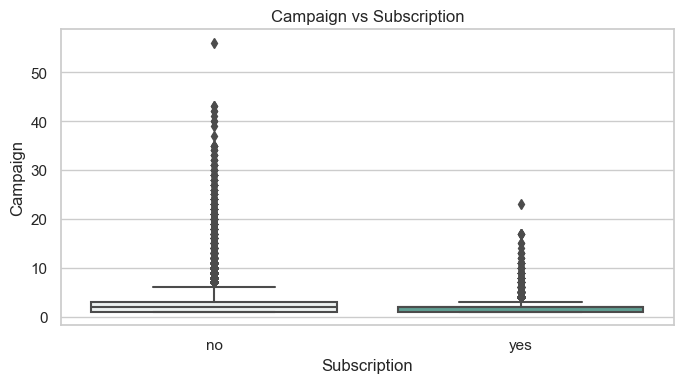

In [287]:
var = 'campaign'

fig, ax = plt.subplots(figsize=(7,4))

sns.boxplot(
    x='y',
    y=var,
    data=df,
    palette="light:#5A9",
    ax=ax
)

ax.set_title(f'{var.capitalize()} vs Subscription')
ax.set_xlabel('Subscription')
ax.set_ylabel(var.capitalize())

plt.tight_layout()

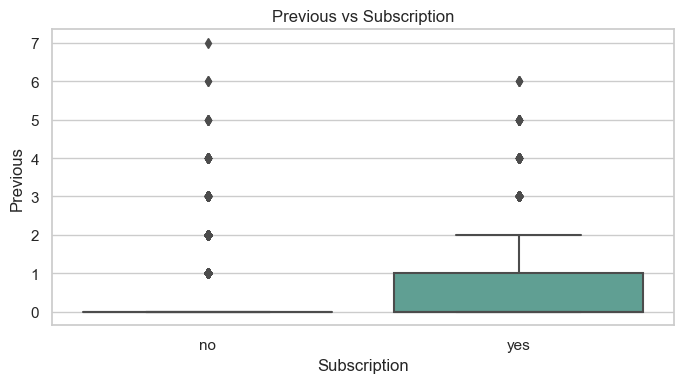

In [288]:
var = 'previous'

fig, ax = plt.subplots(figsize=(7,4))

sns.boxplot(
    x='y',
    y=var,
    data=df,
    palette="light:#5A9",
    ax=ax
)

ax.set_title(f'{var.capitalize()} vs Subscription')
ax.set_xlabel('Subscription')
ax.set_ylabel(var.capitalize())

plt.tight_layout()

               count  conversion_rate
job                                  
student          875         0.314286
retired         1720         0.252326
unemployed      1014         0.142012
admin.         10422         0.129726
management      2924         0.112175
unknown          330         0.112121
technician      6743         0.108260
self-employed   1421         0.104856
housemaid       1060         0.100000
entrepreneur    1456         0.085165
services        3969         0.081381
blue-collar     9254         0.068943


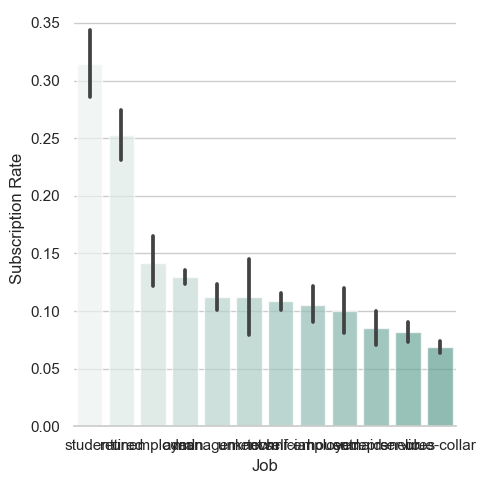

In [290]:
# Ensure binary target exists
df['y_bin'] = df['y'].map({'no': 0, 'yes': 1})

var = 'job'
label = 'Job'

summary = (
    df.groupby(var)
      .agg(count=('y_bin', 'size'),
           conversion_rate=('y_bin', 'mean'))
      .sort_values(by='conversion_rate', ascending=False)
)

print(summary)

g = sns.catplot(
    data=df,
    kind="bar",
    x=var,
    y="y_bin",
    order=summary.index,
    height=5,
    alpha=0.7,
    palette="light:#5A9"
)

g.despine(left=True)
g.set_axis_labels(label, "Subscription Rate")
g.set_titles(f"Conversion Rate by {label}")

                     count  conversion_rate
education                                  
illiterate              18         0.222222
unknown               1731         0.145003
university.degree    12168         0.137245
professional.course   5243         0.113485
high.school           9515         0.108355
basic.4y              4176         0.102490
basic.6y              2292         0.082024
basic.9y              6045         0.078246


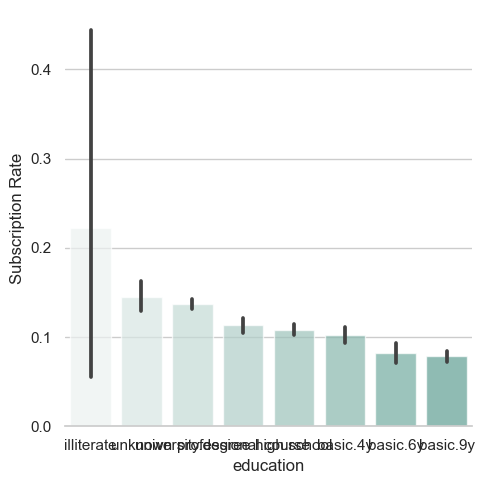

In [291]:
# Ensure binary target exists
df['y_bin'] = df['y'].map({'no': 0, 'yes': 1})

var = 'education'
label = 'education'

summary = (
    df.groupby(var)
      .agg(count=('y_bin', 'size'),
           conversion_rate=('y_bin', 'mean'))
      .sort_values(by='conversion_rate', ascending=False)
)

print(summary)

g = sns.catplot(
    data=df,
    kind="bar",
    x=var,
    y="y_bin",
    order=summary.index,
    height=5,
    alpha=0.7,
    palette="light:#5A9"
)

g.despine(left=True)
g.set_axis_labels(label, "Subscription Rate")
g.set_titles(f"Conversion Rate by {label}")

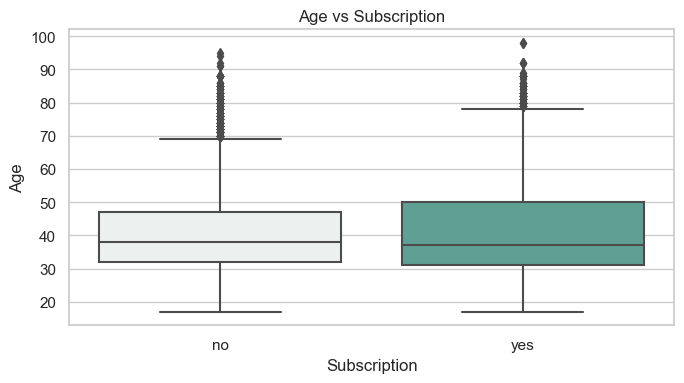

In [289]:
var = 'age'

fig, ax = plt.subplots(figsize=(7,4))

sns.boxplot(
    x='y',
    y=var,
    data=df,
    palette="light:#5A9",
    ax=ax
)

ax.set_title(f'{var.capitalize()} vs Subscription')
ax.set_xlabel('Subscription')
ax.set_ylabel(var.capitalize())

plt.tight_layout()

 Overview

The analysis of medium-impact variables reveals moderate patterns in client behavior, although their predictive strength is less pronounced compared to high-priority features.

From a campaign perspective, the `campaign` variable suggests diminishing returns with repeated contact attempts. Clients who required fewer interactions tend to exhibit higher conversion rates, while increased contact frequency is generally associated with lower success, potentially indicating harder-to-convert cases.

The `previous` variable shows that clients with prior interactions (values greater than zero) tend to have slightly higher conversion rates compared to those with no history. However, the overall variability is limited, as most clients have not been previously contacted.

Among categorical variables, `job` exhibits noticeable differences across segments. Students and retired individuals show significantly higher conversion rates, while blue-collar and service-related occupations tend to convert less. This suggests that occupation may capture meaningful socio-economic differences influencing subscription behavior.

Similarly, the `education` variable shows a gradual trend where higher levels of education are generally associated with better conversion rates. However, some categories, such as "illiterate" and "unknown", display higher rates but are based on relatively small sample sizes, which limits their reliability.

Finally, the `age` variable shows only moderate separation between target classes, indicating that while age may contribute some signal, it is not a strong standalone predictor compared to other features.

#### 8.3 🔹 Low Priority

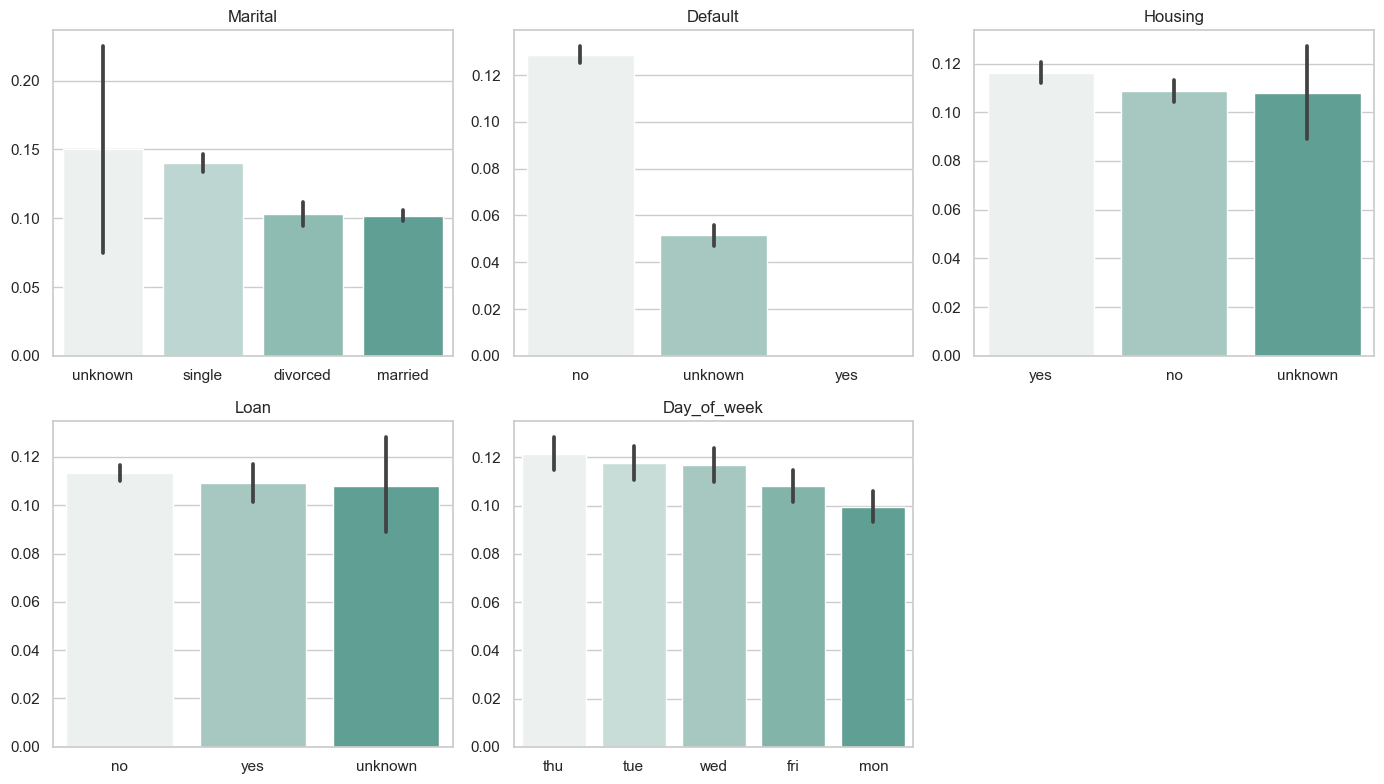

In [292]:
vars_cat = ['marital', 'default', 'housing', 'loan', 'day_of_week']

fig, axes = plt.subplots(2, 3, figsize=(14,8))
axes = axes.flatten()

for i, var in enumerate(vars_cat):
    order = (
        df.groupby(var)['y_bin']
          .mean()
          .sort_values(ascending=False)
          .index
    )
    
    sns.barplot(
        x=var,
        y='y_bin',
        data=df,
        order=order,
        palette="light:#5A9",
        ax=axes[i]
    )
    
    axes[i].set_title(var.capitalize())
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# remove empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()

In [293]:
for var in ['marital', 'default', 'housing', 'loan', 'day_of_week']:
    print(f'\n{var.upper()}')
    display(
        pd.crosstab(df[var], df['y'], normalize='index')
        .sort_values(by='yes', ascending=False)
    )


MARITAL


y,no,yes
marital,,
unknown,0.850000,0.150000
single,0.859959,0.140041
divorced,0.896791,0.103209
married,0.898427,0.101573



DEFAULT


y,no,yes
default,,
no,0.87121,0.12879
unknown,0.94847,0.05153
yes,1.00000,0.00000



HOUSING


y,no,yes
housing,,
yes,0.883806,0.116194
no,0.891204,0.108796
unknown,0.891919,0.108081



LOAN


y,no,yes
loan,,
no,0.886598,0.113402
yes,0.890685,0.109315
unknown,0.891919,0.108081



DAY_OF_WEEK


y,no,yes
day_of_week,,
thu,0.878812,0.121188
tue,0.882200,0.117800
wed,0.883329,0.116671
fri,0.891913,0.108087
mon,0.900517,0.099483


Overview

Low-priority variables show limited differentiation in subscription behavior and therefore provide minimal predictive value.

The `marital` variable exhibits only slight variations, with single individuals showing marginally higher conversion rates compared to married or divorced clients. However, the differences are not substantial enough to be considered strong predictors.

Similarly, the `default` variable indicates that clients without credit default have higher conversion rates, but the "yes" category is extremely rare, limiting its usefulness for modeling.

Both `housing` and `loan` variables display nearly identical conversion rates across categories, suggesting that the presence of financial liabilities does not significantly influence subscription outcomes in this dataset.

Finally, the `day_of_week` variable shows very minor variation, with slightly higher conversions observed on earlier weekdays. Overall, the effect is negligible and likely not meaningful for predictive modeling.

In summary, these variables contribute limited signal and are unlikely to play a major role in model performance compared to higher-priority features.

# 9. Correlation Analysis

**Objective:** Analyze the relationships between numerical variables to identify potential dependencies, redundancy, or multicollinearity that may impact model performance.

The analysis focuses on numerical features, as correlation is primarily meaningful for continuous variables.

### Numerical Variables Considered
- age  
- duration  
- campaign  
- pdays  
- previous  

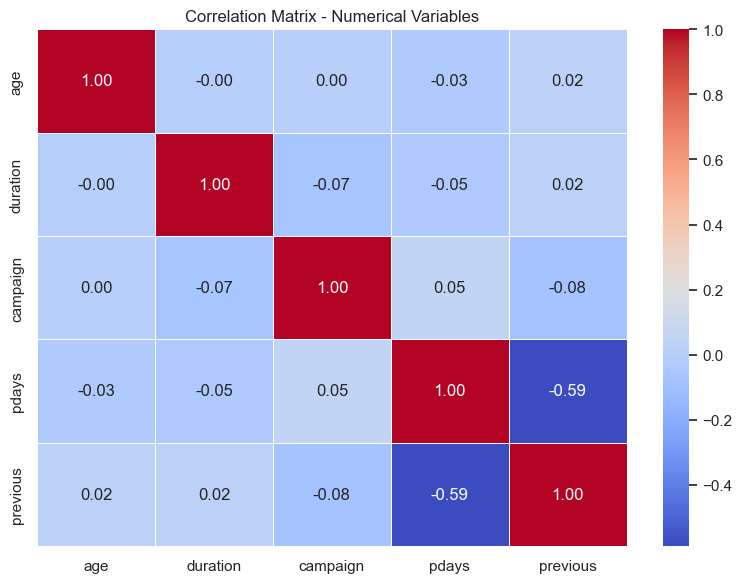

In [294]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical variables
num_vars = ['age', 'duration', 'campaign', 'pdays', 'previous']

# Correlation matrix
corr_matrix = df[num_vars].corr()

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Correlation Matrix - Numerical Variables')
plt.tight_layout()

Overview

The correlation matrix confirms that most numerical variables exhibit very weak linear relationships, indicating that they capture largely independent aspects of client behavior and campaign dynamics.

The only notable relationship appears between `pdays` and `previous`, with a moderate negative correlation (~ -0.59). This is expected, as clients who were contacted more recently tend to have a higher number of previous interactions, while those with `pdays = 999` (not previously contacted) naturally have `previous = 0`. This reflects a structural dependency rather than true predictive redundancy.

All other variables, including `age`, `duration`, and `campaign`, show near-zero correlation with each other. This suggests low multicollinearity and indicates that these features can be used together in modeling without introducing instability due to redundant information.

Overall, the dataset does not present significant multicollinearity concerns, and most numerical variables contribute distinct information to the predictive task.

# 10. Key Insights

## 10. Key Insights

The exploratory analysis reveals several key patterns that define client subscription behavior and provide clear guidance for modeling and decision-making.

### 1. Historical Interaction is the Strongest Signal
The `poutcome` variable is the most powerful predictor in the dataset. Clients with a previously successful campaign outcome show dramatically higher conversion rates, indicating that prior engagement and success are critical drivers of future subscription.

Additionally, variables such as `pdays` and `previous` reinforce this insight, highlighting the importance of client interaction history. The dataset is largely composed of clients without prior contact, which creates a natural segmentation between new and previously engaged clients.

---

### 2. Call Duration is Highly Predictive but Problematic
The `duration` variable shows a strong relationship with the target, where longer calls are significantly associated with successful outcomes. However, this variable introduces data leakage, as it is only known after the interaction occurs.

Therefore, while `duration` can be useful for understanding behavior or building benchmark models, it should be excluded from predictive models intended for real-world deployment.

---

### 3. Campaign Strategy Matters: Less is More
The `campaign` variable suggests diminishing returns with repeated contact attempts. Clients requiring fewer calls tend to convert more, while excessive contact is associated with lower success rates. This may reflect client fatigue or targeting inefficiencies.

---

### 4. Communication Channel and Timing Influence Outcomes
The `contact` variable shows that cellular communication significantly outperforms telephone contact, suggesting that more direct and modern communication channels are more effective.

The `month` variable reveals strong seasonality effects, with certain months (e.g., March, December) achieving substantially higher conversion rates. This indicates that campaign timing plays an important role, although some variability may be influenced by sample size differences.

---

### 5. Socio-Demographic Features Provide Moderate Signal
Variables such as `job` and `education` show meaningful but moderate differences across segments. For example, students and retired individuals tend to convert more, while blue-collar workers show lower conversion rates. Higher education levels are generally associated with better outcomes.

However, these variables are not as strong as behavioral or campaign-related features.

---

### 6. Several Variables Contribute Little Predictive Value
Variables such as `marital`, `housing`, `loan`, and `day_of_week` show minimal variation in conversion rates across categories. Their contribution to predictive performance is likely limited, and they may have low importance in modeling.

---

### 7. Low Multicollinearity Across Features
The correlation analysis confirms that most numerical variables are weakly correlated, indicating that they capture distinct aspects of the data. The only notable relationship (`pdays` vs `previous`) reflects a structural dependency rather than redundancy.

---

### Final Remark
Overall, the most informative features are those related to client interaction history and campaign execution, rather than static demographic attributes. This suggests that modeling efforts should prioritize behavioral and temporal variables, while carefully handling potential data leakage and class imbalance.